<a href="https://colab.research.google.com/github/ImageAcharya/Baseline_Attention_seq2seq/blob/main/baseline_attention_seq2seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import csv
import matplotlib.pyplot as plt

In [ ]:
# Load & Preprocess Data
data = pd.read_csv('Prepared_Nondatabase.csv')


In [ ]:
data

,INPUT,OUTPUT
0,hello,hello! how are you
1,hi there,hi! what’s up
2,hey,hey! how’s it going
3,what’s up,not much! you
4,how’s it going,pretty good! you
...,...,...
174,want to join,sure!
175,what’s cooking,just some pasta
176,how’s the kitchen,cleaned up!
177,need groceries,not right now


In [ ]:

def preprocess_text(text):
    text = text.lower()
    for ch in ["?", "'", ",", ".", "1)", "2)", "3)", "4)"]:
        text = text.replace(ch, " ")
    return text.strip()


In [ ]:

data['INPUT'] = data['INPUT'].apply(preprocess_text)
data['OUTPUT'] = data['OUTPUT'].apply(preprocess_text)


In [ ]:

train_data, val_data = train_test_split(data, test_size=0.1, random_state=42)

In [ ]:
train_data

,INPUT,OUTPUT
68,any updates,nothing much for now
118,miss the old days,yeah sometimes
142,rest up,will try
30,what’s for dinner,still deciding!
9,how’s life,can’t complain you
...,...,...
71,free today,mostly yeah
106,any headaches,gone now thanks
14,where have you been,around! keeping busy
92,missed you!,missed you too!


In [ ]:
val_data

,INPUT,OUTPUT
78,how’s your evening,so far so good!
16,did you sleep well,yes! finally
65,coffee time,always! join me
114,got time to chat,always for you!
76,nice weather,yes! lovely day
19,coffee time,always! join me
122,got your keys,right here!
24,back from work,just got back!
66,lunch yet,about to have it
152,eat well,of course


In [ ]:
#Load Pretrained Tokenizer & Embeddings
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-Embedding-0.6B', padding_side='left')
embedding_model = AutoModel.from_pretrained('Qwen/Qwen3-Embedding-0.6B')

In [ ]:
tokenizer

Qwen2TokenizerFast(name_or_path='Qwen/Qwen3-Embedding-0.6B', vocab_size=151643, model_max_length=131072, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, n

In [ ]:
embedding_model

Qwen3Model(
  (embed_tokens): Embedding(151669, 1024)
  (layers): ModuleList(
    (0-27): 28 x Qwen3DecoderLayer(
      (self_attn): Qwen3Attention(
        (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
        (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
      )
      (mlp): Qwen3MLP(
        (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
        (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
        (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
      (post_attention_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
    )
  )
  (norm): Qwen3RMSNorm((102

In [ ]:
#Custom Dataset Class

class QADataset(Dataset):
    def __init__(self, df, max_len=8192):
        self.df = df
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        q_text = self.df.iloc[idx]['INPUT']
        a_text = self.df.iloc[idx]['OUTPUT']

        q_ids = tokenizer(q_text, truncation=True, max_length=self.max_len, return_tensors="pt")['input_ids'][0]
        a_ids = tokenizer(a_text, truncation=True, max_length=self.max_len, return_tensors="pt")['input_ids'][0]

        return q_ids, a_ids


In [ ]:

train_dataset = QADataset(train_data)
val_dataset = QADataset(val_data)


In [ ]:
train_dataset[0]

(tensor([  3767,   8837, 151643]),
 tensor([ 41212,   1753,    369,   1431, 151643]))

In [ ]:
val_dataset[0]

(tensor([  5158,    748,    697,  11458, 151643]),
 tensor([   704,   3041,    773,   1661,      0, 151643]))

In [ ]:

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)


In [ ]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [ ]:
device

'cuda'

In [ ]:
# Encoder Class

class BiLSTMEncoder(nn.Module):
    def __init__(self, hidden_size, embed_dim=1024):
        super().__init__()
        self.encoder = nn.LSTM(embed_dim, hidden_size, dropout=0.2, batch_first=True, bidirectional=True)

    def forward(self, x):
        enc_out, (h, c) = self.encoder(x)
        h_cat = torch.cat([h[0], h[-1]], dim=-1)
        c_cat = torch.cat([c[0], c[-1]], dim=-1)
        return enc_out, h_cat, c_cat


In [ ]:
# Decoder with Attention

class AttentionDecoder(nn.Module):
    def __init__(self, embed_model, vocab_size, hidden_size, embed_dim=1024):
        super().__init__()
        self.embed_model = embed_model
        self.encoder = BiLSTMEncoder(hidden_size, embed_dim)
        self.decoder = nn.LSTMCell(embed_dim, hidden_size*2)
        self.vocab_size = vocab_size

        # Attention layers
        self.attn1 = nn.Linear(hidden_size*4, hidden_size)
        self.attn2 = nn.Linear(hidden_size, hidden_size)
        self.attn_score = nn.Linear(hidden_size, 1)

        # Output projection
        self.output_proj = nn.Linear(hidden_size*4, vocab_size)

    def compute_attention(self, dec_hidden, enc_outputs):
        B, T, H = enc_outputs.shape
        dec_exp = dec_hidden.unsqueeze(1).expand(-1, T, -1)
        combined = torch.cat([enc_outputs, dec_exp], dim=2)
        x = torch.tanh(self.attn1(combined))
        x = torch.tanh(self.attn2(x))
        scores = self.attn_score(x).squeeze(-1)
        attn_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        concat = torch.cat([dec_hidden, context], dim=1)
        vocab_logits = self.output_proj(concat)
        return vocab_logits

    def forward(self, inputs, targets, teacher_forcing_ratio=1.0):
        seq_len = len(targets)
        enc_out, h, c = self.encoder(inputs)
        logits_list = []

        dec_input = targets[0][0]
        for t in range(1, seq_len):
            h, c = self.decoder(dec_input, (h, c))
            vocab_logits = self.compute_attention(h, enc_out)
            logits_list.append(vocab_logits)

            if torch.rand(1).item() < teacher_forcing_ratio:
                dec_input = targets[t][0]
            else:
                pred_tokens = torch.argmax(vocab_logits, dim=1)
                with torch.no_grad():
                    dec_input = self.embed_model(pred_tokens.unsqueeze(0))['last_hidden_state'][0].detach()

        return torch.stack(logits_list, dim=1)

In [ ]:
#Initialize Model

vocab_size = len(tokenizer.vocab)
model = AttentionDecoder(embed_model=embedding_model, vocab_size=vocab_size, hidden_size=320, embed_dim=1024).to(device)


/home/Image/Documents/Image/imgenv/lib/python3.10/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [ ]:

start_token = tokenizer('<|im_start|>', return_tensors='pt')['input_ids'][:,0].unsqueeze(0).to(device)
learning_rate = 0.001
epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# Training Loop
train_losses, train_accuracies, val_losses, val_accuracies = [], [], [], []
best_val_loss = float('inf')  # for saving best model
for epoch in range(epochs):
    model.train()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    for input_ids, target_ids in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        input_ids, target_ids = input_ids.to(device), target_ids.to(device)
        input_ids = input_ids[:, :-1]
        start_exp = start_token.expand(target_ids.size(0), 1).to(device)
        targets_with_sos = torch.cat([start_exp, target_ids], dim=1)

        optimizer.zero_grad()
        with torch.no_grad():
            input_embeds = embedding_model(input_ids)['last_hidden_state'].detach()
            target_embeds = [embedding_model(i.unsqueeze(0).unsqueeze(0))['last_hidden_state'].detach() for i in targets_with_sos[0]]

        logits = model(input_embeds, target_embeds, teacher_forcing_ratio=1)
        loss = criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        total_correct += (preds == target_ids).float().sum().item()
        total_tokens += target_ids.numel()

    avg_train_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_tokens
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_total_loss, val_total_correct, val_total_tokens = 0.0, 0, 0
    with torch.no_grad():
        for val_inp, val_tgt in tqdm(val_loader, desc="Validation: "):
            val_inp, val_tgt = val_inp.to(device), val_tgt.to(device)
            val_inp = val_inp[:, :-1]
            val_start = start_token.expand(val_tgt.size(0), 1).to(device)
            val_targets_with_sos = torch.cat([val_start, val_tgt], dim=1)

            val_inp_embeds = embedding_model(val_inp)['last_hidden_state'].detach()
            val_target_embeds = [embedding_model(i.unsqueeze(0).unsqueeze(0))['last_hidden_state'].detach() for i in val_targets_with_sos[0]]

            val_logits = model(val_inp_embeds, val_target_embeds, teacher_forcing_ratio=1)
            val_loss = criterion(val_logits.view(-1, val_logits.size(-1)), val_tgt.view(-1))

            val_total_loss += val_loss.item()
            val_preds = torch.argmax(val_logits, dim=-1)
            val_total_correct += (val_preds == val_tgt).float().sum().item()
            val_total_tokens += val_tgt.numel()

    avg_val_loss = val_total_loss / len(val_loader)
    val_acc = val_total_correct / val_total_tokens
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "models/best_model_weight.pth")
    torch.save(model.state_dict(), f"models/model_weightepoch_{epoch+1}.pth")


    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")


Validation: 100%|██████████| 18/18 [00:00<00:00, 18.41it/s]


Epoch 1: Train Loss=6.6093, Train Acc=0.2280 | Val Loss=5.5038, Val Acc=0.2500


Validation: 100%|██████████| 18/18 [00:00<00:00, 18.46it/s]


Epoch 2: Train Loss=4.2384, Train Acc=0.2400 | Val Loss=5.4343, Val Acc=0.2159


Validation: 100%|██████████| 18/18 [00:01<00:00, 16.51it/s]


...

Epoch 48: Train Loss=0.6573, Train Acc=0.7093 | Val Loss=4.5900, Val Acc=0.4886


Validation: 100%|██████████| 18/18 [00:01<00:00, 14.25it/s]


Epoch 49: Train Loss=0.6841, Train Acc=0.7093 | Val Loss=4.4559, Val Acc=0.5114


Validation: 100%|██████████| 18/18 [00:00<00:00, 18.20it/s]


Epoch 50: Train Loss=0.6440, Train Acc=0.7133 | Val Loss=4.4950, Val Acc=0.4886


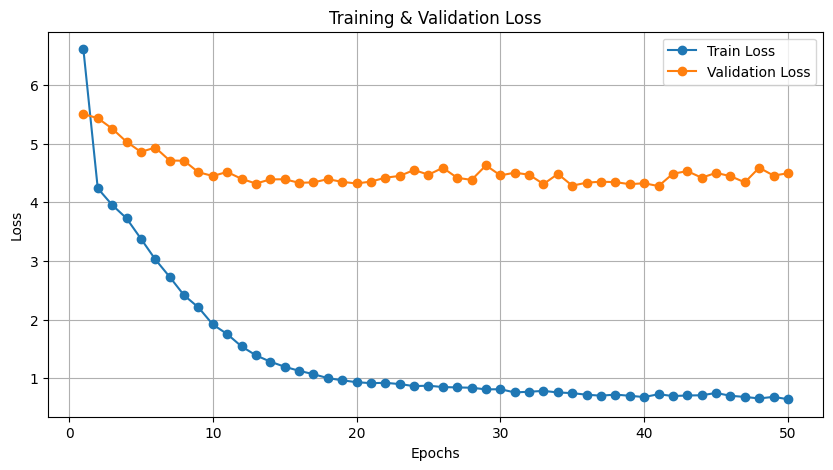

In [ ]:
# Plot Loss

plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


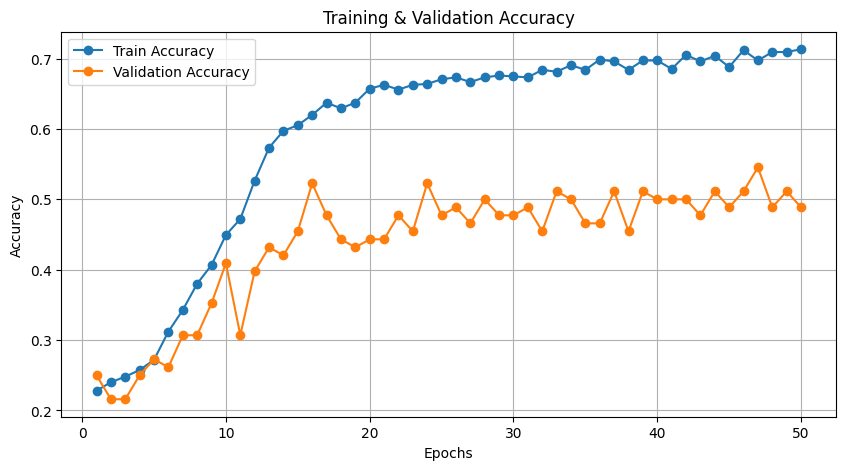

In [ ]:
# Plot Accuracy

plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), train_accuracies, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Inference Function

def inference(model, tokenizer, embed_model, device, queries, max_len=20):

    model.eval()
    embed_model = embed_model.to(device)

    for query in queries:
        print("Your Query:", query)

        # Encode input query
        input_ids = tokenizer(query, max_length=8192, truncation=True, return_tensors="pt")['input_ids'][:, :-1].to(device)
        input_embeds = embed_model(input_ids)['last_hidden_state']
        enc_out, hidden, cell = model.encoder(input_embeds)

        # Start token embedding
        start_token_id = tokenizer('<|im_start|>', return_tensors="pt")['input_ids'][:, 0].unsqueeze(0).to(device)
        input_emb = embed_model(start_token_id)['last_hidden_state'][:, 0, :]

        generated_tokens = []

        for _ in range(max_len):
            hidden, cell = model.decoder(input_emb, (hidden, cell))
            vocab_logits = model.compute_attention(hidden, enc_out)
            next_token_id = torch.argmax(vocab_logits, dim=1).item()

            if next_token_id == 151643:  # stop token
                break

            generated_tokens.append(next_token_id)
            input_emb = embed_model(torch.tensor([[next_token_id]]).to(device))['last_hidden_state'][:, 0, :]

        # Decode generated token ids
        response_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
        print("Model Response:", response_text)
        print("-"*50)  # separator for readability



In [ ]:
# Example Usage

queries_list = [
    "Hello good morning sir",
    "I'm really sorry for late submission",
    "Did you sleep well the night?",
    "Any plan for today?"

]

inference(model, tokenizer, embedding_model, device, queries_list)


Your Query: Hello good morning sir
Model Response: good morning morning well
--------------------------------------------------
Your Query: I'm really sorry for late submission
Model Response: yeah     
--------------------------------------------------
Your Query: Did you sleep well the night?
Model Response: yes!!!!!
--------------------------------------------------
Your Query: Any plan for today?
Model Response: just yet   
--------------------------------------------------
